In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import sys
import warnings
import nest_asyncio
nest_asyncio.apply()  # 중첩 이벤트 루프 허용
import os
import json
import logging
import asyncio
import pandas as pd
import openai
from datetime import datetime
import sys
from typing import List, Dict, Optional
from tenacity import retry, stop_after_attempt, wait_exponential
import re

warnings.simplefilter(action='ignore', category=FutureWarning) # FutureWarning 제거

In [2]:
df = pd.read_excel('../../data/centum_data/21.11-24.6환자 CC_PI_치료계획.xlsx')
df['날짜'] = pd.to_datetime(df['날짜'])
df = df.iloc[:,1:]

df.columns = df.columns.str.strip()
df = df[['환자번호', '날짜', 
        # 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI',  # 처리 됨.
        'CMO','MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading', 'Occlusion', 'OJ/OB',
        'Class', 'Midline Shift', 'Deviation', 'CR-CO', 'Tongue ridging',
        'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt',
        'Lateral excursion Protrusive excursion', 'End feel', 
       '치료계획', # 필요 없을 듯.
    #    'T-scan 악화/개선', 'CBCT 악화/개선', 'CBCT 판독소견' # 고유겂 NaN    
    ]]

df = df[['환자번호', '날짜',
        'CMO','MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading', 'Occlusion', 'OJ/OB',
        'Class', 'Midline Shift', 'Deviation', 'CR-CO', 'Tongue ridging',
        'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt',
        '치료계획', 'End feel']]

In [3]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel'],
      dtype='object')

### CMO & MMO
CMO : 입을 편하게 벌릴 수 있는 최대 크기 \
MMO : 입을 아프더라도 벌릴 수 있는 최대 크기
- 스킴
    - 벌려지는 정도 & 위치 & 처방 종류
    - 화살표 이후의 정보 삭제
    - 고착, 스프레이 필요 없음


In [4]:
df.sample(10).MMO


22123                     mm after spray and stretch
17774                                           40mm
19924    38mm no pain-->  mm after spray and stretch
16099      53mm n/p --> 58mm after spray and stretch
8157      23mm --> 고착 후 48mm after spray and stretch
2588             50mm --> mm after spray and stretch
3797                                             NaN
24929         43mm --> mm after spray and stretch 고착
23496           44 mm --> mm after spray and stretch
4919             47mm --> mm after spray and stretch
Name: MMO, dtype: object

In [5]:
df.sample(10).CMO

17072    42mm --> 44mm after spray and stretch
18018                                     50mm
3191       54mm --> mm after spray and stretch
23848      47mm --> mm after spray and stretch
26391      33mm --> mm after spray and stretch
3011       42mm --> mm after spray and stretch
24882      52mm --> mm after spray and stretch
16458      30mm --> mm after spray and stretch
20933      44mm --> mm after spray and stretch
18868                        32mm -> 고착 후 38mm
Name: CMO, dtype: object

In [6]:
def extract_number(text):
    """
    텍스트에서 숫자를 추출하는 함수
    NaN 값이나 None 값도 처리 가능
    """
    # NaN, None 또는 비문자열 타입 처리
    if pd.isna(text) or text is None or not isinstance(text, str):
        return '', ''
    
    # 패턴 1: "숫자 mm --> 숫자 mm" 형태 (공백 허용)
    pattern1 = r'(\d+)\s*mm\s*-->\s*(\d+)\s*mm'
    match1 = re.search(pattern1, text)
    
    if match1:
        return match1.group(1), match1.group(2)  # 앞, 뒤 숫자 모두 반환
    
    # 패턴 2: "숫자 mm --> mm" 형태 (뒤 숫자 없음, 공백 허용)
    pattern2 = r'(\d+)\s*mm\s*-->\s*mm'
    match2 = re.search(pattern2, text)
    
    if match2:
        return match2.group(1), ''  # 앞 숫자만 반환, 뒤는 빈 문자열
    
    # 패턴 3: 단순히 "숫자 mm" 형태 (공백 허용)
    pattern3 = r'(\d+)\s*mm'
    match3 = re.search(pattern3, text)
    
    if match3:
        return match3.group(1), ''  # 앞 숫자만 반환, 뒤는 빈 문자열
    
    return '', ''  # 숫자를 찾지 못한 경우 빈 문자열 두 개 반환

In [7]:
# CMO
result = df.CMO.apply(extract_number)
df['CMO_before'], df['CMO_after'] = zip(*result)
# MMO
result = df.MMO.apply(extract_number)
df['MMO_before'], df['MMO_after'] = zip(*result)

### Deviation
입을 벌리면서 위 턱에 대해 아래 턱이 어떻게 움직이는지 경로를 나타내는 열

- 스킴
    - 방향 & 이동 경로 & 치우침의 강도 or 증상
    - L이 가장 안좋음. S는 낫배드.
    - L, S가 중요하며, 강도는 크게 중요하지 않음.
    고착 후 등 다 필요 없다.

In [8]:
df.Deviation.unique()



array([nan, 'L (Lt)', '-', 'R', 'S', '왼L', '왼 L', 'RT) L', '오른쪽 S',
       '오른쪽 S, 벌리고 다물때', 'Rt)L', 'Lt) L', 'RT', '오 L', '오 S', 'Rt', '오L',
       'Lt', 'Lt L 심함', '오', '오른쪽', 'LT', 'L', 'Lt) S', 'Rt) L',
       '안풀고도 심함,풀어서 L 심함', 'S로 약하게', 'S (Rt)', 'Lt 많이 좋아짐', '오른쪽L',
       '오른쪽L /고착 후  오L없어지고 S로 바뀜', 'Lt)L', 'RT)L 약간', 'RT)L',
       'mild L deviation', 's', '없음', 'Lt L', '오른쪽 L', 'n/s', 'Rt) S 거칠게',
       'Rt) S ->거의없음', 'Rt)S', 'Lt S', 'Rt L', 'Rt) L 의심', 'Rt) S',
       'Lt L -> S after spray', 'L왼', '왼L심함', '오s', 'S 심함', 'L,S 중간정도',
       'S(Rt)', 's 심함', '약간 Rt', '오른쪽 L 약간', 'Rt) L 마지막에 원래대로 돌아옴',
       'LT) L', 'Lt)L 있었던적 있음', 'Lt) S,L 중간', 'S (왼쪽으로 갔다가 가운데)', '오l',
       's심함', 'RT L', '왼L++', '안틀면 오L', '왼쪽L', '왼쪽l', '왼쪽 L 거의없음', 'L 살짝',
       'Z', 'both L', '약간 s', 'R 많이 기울어짐', '오S', 'S심함', '왼S',
       'L->S(고착 후)', 'S 약하게', '왼L (양쪽 걸린 느낌)', '양쪽L',
       'S 벌릴때 오른쪽->다물때 왼쪽->', '오L+S중간', '오l경향성', '살짝 L', 'S, L 중간',
       'S (가끔씩 Rt L)', 'R(S)', 'R(L)', 'L(L)', 'R

In [9]:
import re
import pandas as pd
from collections import Counter

def extract_pattern_info(text):
    """
    Extract pattern type, direction, and intensity from a single deviation description.
    
    Args:
        text (str): A deviation description string
        
    Returns:
        tuple: (pattern_type, direction, intensity)
    """
    # Initialize values
    pattern_type = []
    direction = 'unspecified'
    intensity = 'normal'
    
    # Skip NaN values
    if not isinstance(text, str) or text.lower() == 'nan':
        return ('other', direction, intensity)
    
    # Extract pattern type (L, S)
    if re.search(r'(?i)(?:^|\s|[,(])L(?:$|\s|[,)]|t\)|\()', text):
        pattern_type.append('L')
    if re.search(r'(?i)(?:^|\s|[,(])S(?:$|\s|[,)]|t\)|\()', text):
        pattern_type.append('S')
    
    # Extract direction
    left_match = re.search(r'(?i)(?:왼|왼쪽|lt|LT)', text)
    right_match = re.search(r'(?i)(?:오|오른|오른쪽|rt|RT)', text)
    
    if left_match and right_match:
        direction = 'both'
    elif left_match:
        direction = 'left'
    elif right_match:
        direction = 'right'
    
    # Extract intensity
    if re.search(r'(?i)(?:심함|많이|\+\+)', text):
        intensity = 'severe'
    elif re.search(r'(?i)(?:약간|약하게)', text):
        intensity = 'mild'
    elif re.search(r'(?i)(?:거의 없음|없음)', text):
        intensity = 'none'
    elif re.search(r'(?i)(?:중간|중간정도)', text):
        intensity = 'moderate'
        
    # Convert pattern_type list to string
    pattern_type = '+'.join(pattern_type) if pattern_type else 'other'
    
    return (pattern_type, direction, intensity)

def analyze_deviation_patterns(df, col_name='Deviation'):
    """
    Analyze deviation patterns in a dataframe column and add new columns for pattern type, 
    direction, and intensity.
    
    Args:
        df (pandas.DataFrame): DataFrame containing the deviation column
        col_name (str): Name of the column containing deviation descriptions
        
    Returns:
        pandas.DataFrame: Original dataframe with 3 new columns added
    """
    # Make a copy of the dataframe to avoid modifying the original
    df_result = df.copy()
    
    # Apply the extraction function to each row of the specified column
    df_result[['deviation_pattern_type', 'deviation_direction', 'deviation_intensity']] = df_result[col_name].apply(
        lambda x: pd.Series(extract_pattern_info(x))
    )
    
    return df_result


In [10]:
df = analyze_deviation_patterns(df)

In [11]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity'],
      dtype='object')

### Cap.pal & M.pal
씹을때의, 근육의 통증? Cap = 뼈, M 근육

- 스킴
    - 위치 & 강도 & 조건부 상황
    - +,- > + 순으롤 아파짐. (공백은 + 하나)
    - -가 되는 것이 목표



In [12]:
list(set(df['Cap.pal'].unique().tolist()))

['rt)CAP+',
 'rt)capsul 아랫부분',
 'lt+',
 'Rt cap pos+',
 'rt cap-크게벌릴때',
 'Lt)바깥쪽+',
 'both) +, (Lt > Rt)',
 'RT)++  Lt)+',
 'Rt)+ 벌릴때(옆+뒤)',
 'Rt)CAP',
 'both cap) +',
 'Lt) cap + .',
 'Rt(+)',
 'rt)옆,뒤+',
 'Rt) +/- R>L 감소했지만 남아있음',
 'Lt) Cap+',
 'both cap(Lt>RT)',
 'Rt) pain +/-',
 'Rt cap 뒤쪽 +',
 'Lt +',
 'Both)Cap+ (Lt 더)',
 'rt) +/- lt) ++',
 'Rt + cap',
 'BOTH',
 'Rt 남아있음',
 'Lt) closing click',
 'BOTH CAP (R>L)',
 'BOTH) 뒤쪽+',
 'both cap (Rt>Lt)',
 'BOTH CAP (LT>RT)',
 'Rt) 뒷쪽+',
 'capsule 괜찮음',
 'Rt cap +/-감소',
 nan,
 'Rt + 감소',
 'LT',
 '개구 시 Rt +',
 'RT) +',
 'BOTH) cap',
 '개구시 cap +',
 'Rt',
 '양쪽 capsule',
 'Rt)+바깥쪽',
 'rt(+/-)',
 'RT)+, 열감',
 'Lt)cap-',
 'RT +,-',
 'Rt)옆,뒤+',
 'Rt)뒤쪽 +',
 'rt cap',
 'rt) +++',
 'both)+ (Rt>Lt)',
 '턱떨림감소',
 'LT CAP 뻐근',
 '- , LT)+ 입벌리거나,턱 오른쪽으로 할 때',
 '씹을때 Rt) cap+',
 'both)+옆쪽',
 'Lt) + (눌렀다가 뗄때)',
 'Rt) 감소',
 'both) cap +,-',
 'Rt) cap 조금 남아있음',
 'Rt) CAP+',
 'Rt 아래뒷쪽 조금남음',
 'LT) cap +',
 'Rt +-',
 'Lt) cap+ (조금감소)',
 'both) cap ++',
 'lt) 

In [13]:
import re
import pandas as pd
import numpy as np

def classify_capsule_pain(text):
    """
    Capsule pain 텍스트에서 통증 강도, 방향, 상황을 추출하는 함수
    
    Args:
        text (str): Capsule pain 설명 텍스트
        
    Returns:
        tuple: (intensity, direction, situation)
            - intensity (int): 통증 강도 (-1=없음, 0=+/-, 1=+, 2=++, 3=+++)
            - direction (str): 방향 ('left', 'right', 'both', 'unspecified')
            - situation (str): 발생 상황
    """
    # 입력값이 NaN이거나 비어있는 경우 기본값 반환
    if pd.isna(text) or text == '-' or text == '.' or text == '-.' or text == '-,' or text == '':
        return (0, 'unspecified', '')
    
    # 통증 강도 추출
    intensity = 0  # 기본값: 통증 없음
    
    # 통증 없음 패턴
    if re.search(r'(?:괜찮|감소|없음|거의 없음|n\/s|N\/S|-$|-\.|cap-|감소했|캡술 괜찮음)', text):
        intensity = 0
    # +/- 패턴
    elif re.search(r'(?:\+\/\-|\+\/-|약간|\+,\-|\+-|\-\+)', text):
        intensity = 1
    # +++ 패턴
    elif re.search(r'(?:\+\+\+|\+\+\+\+|\+\+\+)', text):
        intensity = 2
    # ++ 패턴
    elif re.search(r'(?:\+\+|\+\+,|\+\+ )', text):
        intensity = 3
    # + 패턴 (다른 패턴이 없을 경우)
    elif re.search(r'(?:\+|\+,|\+ )', text) and not re.search(r'(?:\+\+|\+\/\-|\+\+\+)', text):
        intensity = 0
    
    # 방향 추출
    direction = 'unspecified'  # 기본값: 방향 미지정
    
    # 양방향 패턴
    if re.search(r'(?i)(?:both|양쪽)', text):
        direction = 'both'
    # 왼쪽 패턴
    elif re.search(r'(?i)(?:lt|왼쪽|LT|Lt|lt\)|Lt\)|LT\))', text) and not re.search(r'(?i)(?:rt|오른|RT|Rt|rt\)|Rt\)|RT\))', text):
        direction = 'left'
    # 오른쪽 패턴
    elif re.search(r'(?i)(?:rt|오른|RT|Rt|rt\)|Rt\)|RT\))', text) and not re.search(r'(?i)(?:lt|왼쪽|LT|Lt|lt\)|Lt\)|LT\))', text):
        direction = 'right'
    # 양쪽 모두 언급된 경우
    elif re.search(r'(?i)(?:lt|왼쪽|LT|Lt)', text) and re.search(r'(?i)(?:rt|오른|RT|Rt)', text):
        direction = 'both'
    
    # 상황 추출
    situation = ''
    
    # 입을 벌릴 때 패턴
    if re.search(r'(?:벌릴|벌리|개구|opening)', text):
        situation = '벌릴 때'
    # 입을 다물 때 패턴
    elif re.search(r'(?:다물|물 때|closing|폐구)', text):
        situation = '다물 때'
    # 씹을 때 패턴
    elif re.search(r'(?:씹을|저작)', text):
        situation = '씹을 때'
    # 누를 때 패턴
    elif re.search(r'(?:누를|누르)', text):
        situation = '누를 때'
    # 움직일 때 패턴
    elif re.search(r'(?:움직|틀)', text):
        situation = '움직일 때'
    # 고착 시 패턴
    elif re.search(r'(?:고착)', text):
        situation = '고착 시'
    
    return (intensity, direction, situation)

def expand_capsule_pain_dataframe(sp, pain_column='Cap.pal'):
    """
    데이터프레임에 통증 강도, 방향, 상황 열을 추가하는 함수
    
    Args:
        sp (pandas.DataFrame): 통증 정보가 포함된 데이터프레임
        pain_column (str): 통증 정보가 저장된 열 이름
        
    Returns:
        pandas.DataFrame: 확장된 데이터프레임
    """
    # 원본 데이터프레임 복사
    sp_result = sp.copy()
    
    # 분류 함수 적용
    classified_data = sp_result[pain_column].apply(classify_capsule_pain)
    if pain_column == 'Cap.pal':
        # 결과 열 추가
        sp_result['Cap.pal_Pain_Intensity'] = classified_data.apply(lambda x: x[0])
        sp_result['Cap.pal_Pain_Direction'] = classified_data.apply(lambda x: x[1])
        sp_result['Cap.pal_Pain_Situation'] = classified_data.apply(lambda x: x[2])
    
    elif pain_column == 'M.pal':
        sp_result['M.pal_Pain_Intensity'] = classified_data.apply(lambda x: x[0])
        sp_result['M.pal_Pain_Direction'] = classified_data.apply(lambda x: x[1])
        sp_result['M.pal_Pain_Situation'] = classified_data.apply(lambda x: x[2])
    # 통증 강도 매핑 사전 (필요시 표시용)
    
    # intensity_map = {
    #     -1: '없음',
    #     0: '+/-',
    #     1: '+',
    #     2: '++',
    #     3: '+++'
    # }
    # if pain_column == 'Cap.pal':    
    #     sp_result['Cap.pal_Pain_Intensity_Label'] = sp_result['Cap.pal_Pain_Intensity'].map(intensity_map)
    # elif pain_column == 'M.pal':
    #     sp_result['M.pal_Pain_Intensity_Label'] = sp_result['M.pal_Pain_Intensity'].map(intensity_map)
    
    return sp_result

def generate_pain_statistics(sp):
    """
    통증 정보에 대한 통계를 생성하는 함수
    
    Args:
        sp (pandas.DataFrame): 분류된 통증 정보가 포함된 데이터프레임
        
    Returns:
        dict: 통계 정보 딕셔너리
    """
    stats = {
        'total_items': len(sp),
        'intensity_counts': sp['Pain_Intensity'].value_counts().to_dict(),
        'direction_counts': sp['Pain_Direction'].value_counts().to_dict(),
        'situation_counts': sp['Pain_Situation'].value_counts().to_dict(),
        'intensity_by_direction': {},
        'situation_by_direction': {}
    }
    
    # 방향별 강도 분포
    for direction in sp['Pain_Direction'].unique():
        direction_sp = sp[sp['Pain_Direction'] == direction]
        stats['intensity_by_direction'][direction] = direction_sp['Pain_Intensity'].value_counts().to_dict()
    
    # 방향별 상황 분포
    for direction in sp['Pain_Direction'].unique():
        direction_sp = sp[sp['Pain_Direction'] == direction]
        stats['situation_by_direction'][direction] = direction_sp['Pain_Situation'].value_counts().to_dict()
    
    return stats

# def print_pain_statistics(stats):
#     """
#     통증 통계 정보를 출력하는 함수
    
#     Args:
#         stats (dict): 통계 정보 딕셔너리
#     """
#     # 강도 매핑
#     intensity_map = {
#         -1: '없음',
#         0: '+/-',
#         1: '+',
#         2: '++',
#         3: '+++'
#     }
    
#     print(f"총 분석 항목: {stats['total_items']}")
    
#     print("\n--- 통증 강도 통계 ---")
#     for intensity, count in sorted(stats['intensity_counts'].items()):
#         percentage = round(count / stats['total_items'] * 100, 2)
#         intensity_label = intensity_map.get(intensity, str(intensity))
#         print(f"{intensity_label}: {count}개 ({percentage}%)")
    
#     print("\n--- 방향 통계 ---")
#     for direction, count in stats['direction_counts'].items():
#         percentage = round(count / stats['total_items'] * 100, 2)
#         print(f"{direction}: {count}개 ({percentage}%)")
    
#     print("\n--- 상황 통계 ---")
#     for situation, count in stats['situation_counts'].items():
#         if situation == '':
#             situation = '미지정'
#         percentage = round(count / stats['total_items'] * 100, 2)
#         print(f"{situation}: {count}개 ({percentage}%)")
    
#     print("\n--- 방향별 강도 분포 ---")
#     for direction, intensities in stats['intensity_by_direction'].items():
#         print(f"{direction}:")
#         direction_total = sum(intensities.values())
#         for intensity, count in sorted(intensities.items()):
#             percentage = round(count / direction_total * 100, 2)
#             intensity_label = intensity_map.get(intensity, str(intensity))
#             print(f"  - {intensity_label}: {count}개 ({percentage}%)")

# # 예시 사용법
# if __name__ == "__main__":
#     # 예시 데이터프레임
#     data = df['Cap.pal']
    
#     sp = pd.DataFrame(data)
    
#     # 데이터프레임 확장
#     sp_expanded = expand_capsule_pain_dataframe(sp)

#     # 결과 확인
#     print(sp_expanded[['Cap.pal', 'Pain_Intensity', 'Pain_Direction', 'Pain_Situation', 'Pain_Intensity_Label']])
    
#     # 통계 생성 및 출력
#     stats = generate_pain_statistics(sp_expanded)
#     print_pain_statistics(stats)

In [14]:
df = expand_capsule_pain_dataframe(df,"Cap.pal")
df = expand_capsule_pain_dataframe(df,"M.pal")

In [15]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation'],
      dtype='object')

### Noise
관절 움직임 시 소음?

- 스킴
    - 위치 & 소음종류(click, snap, pop, etc) & (조건부 상황 or 빈도)
    - popping : 밖에서 들리는 소리, click : 밖에서 안들리는 소리, creptitus : 뼈갈리는 소리
    - creptitus, popping : bad. click : good. bad 에서 good 으로 가는게 목표
    



In [16]:
df[(df['Noise'].notna()) & (df['Noise'] != '-')].sample(20)['Noise']

5848                            Rt)단순click도 있음
2879                              고착후 lt)click
18634                               BOTH)CLICK
1124                                both)click
6879                                  Rt)click
125                               Rt) click 심함
4098                                  Rt)click
2033                                  Rt)click
83                            -click / popping
17686                         -click / popping
17401                       Lt) click 벌릴때, 다물때
1664                                     거의 없음
11053                         both)click 간헐적으로
10607                            LT)POPPING 한번
13977    Lt)click ( 환자분께서는 박동성 울리는 소리 들린다고 하심)
13378                           Rt popping 약하게
14375                    Lt) click, 덜컹거림 거의 없음
14742                         -click / popping
12934                         -click / popping
18833                                      n/s
Name: Noise, dtype: object

In [17]:
list(set(df.Noise.tolist()))

['Lt+click  -> 고착 후 Lt click괜찮음, Lt0 popping 한번',
 'RT)popping작게',
 '크게 벌릴때 popping',
 'Rt)click Lt)popping',
 'LT  CLICK 거의 없음',
 'click평소 있으나 오늘 X',
 'LT)closing click /초음파도 lt click',
 'Rt) click + / popping',
 'Lt) click, popping한번',
 'lt) popping 환자분 말씀으론 간헐적으로 있다고 하심',
 'Lt) click / crepitus 작아지는걸로 보임',
 'Lt)click 거의 없음',
 '거의없음(덜컥거리는 정도)',
 'Lt popping 1번 있었음',
 'Rt 감소',
 'Rt)popping-> 없어지는 경향성',
 'Lt)click / Rt) popping',
 'both click + popping중간',
 'LT click',
 'LT click / 양쪽으로 틀 때',
 'both) closing click 많이 감소',
 'both)click(rt가 더)',
 nan,
 'both) click (Lt-> 마지막에 Rt)',
 'rt)click 명확하지 않음,  소리는 마지막에 덜컥',
 'both(lt click거침)',
 'Lt) click 약간',
 'both) closing 시 click',
 'Rt)click   Lt)click 벌릴때, 다물때',
 'Lt click, popping',
 'Rt 소리 히스토리',
 'Rt) 벌릴 때, 닫을 때 click 약간',
 'Lt) popping 간헐적',
 '간헐적으로 소리 아직은 남아있음',
 '양쪽 +click',
 'Lt ) click 작음',
 '소리 거의 없음',
 'rt)덜컥거리는 정도',
 'Lt) click, 간헐적 Popping',
 'BOTH click / LT popping',
 'lt click 거의 없음',
 'Rt popping 벌리고 다물떄 / CO bite 시 소리없음',

In [18]:
import re
import pandas as pd

def classify_tmj_noise(text):
    """
    TMJ(악관절) 소음 텍스트에서 아래 정보를 추출:
    
    - noise_code (int)       : 0=없음, 1=click, 2=popping, 3=crepitus 중 가장 나쁜 소리
    - noise_direction (str)  : 'left', 'right', 'both', 'none'
    - noise_intensity (int)  : 0=미약, 1=약간, 2=심함 (예시 기준)
    - noise_situation (str)  : '벌릴 때', '다물 때', '씹을 때', '누를 때', '움직일 때', '하품할 때', '고착 시', ''
    
    Args:
        text (str): 소음 관련 텍스트(문장)
    Returns:
        tuple: (noise_code, noise_direction, noise_intensity, noise_situation)
    """
    # (1) 결측/예외처리
    if not isinstance(text, str) or text.strip() in ['', '-', '.', '-.', '-,']:
        return (0, 'none', 0, '')
    
    text_lower = text.lower().strip()
    
    #-------------------------------------------------
    # (2) 소음 코드 판별
    #    - crepitus(3), popping(2), click(1)
    #    - 여러 개 섞여 있으면 가장 큰 값(“나쁜 소리”) 우선
    #-------------------------------------------------
    left_code = 0
    right_code = 0
    
    # 2-1) 문장 전체에서 crepitus / popping / click 중 제일 큰 소음 찾기
    #     (우선 단일 'noise_code'를 구한 뒤, left/right 반영)
    noise_code_tmp = 0
    
    # crepitus(3) - 'crepitus', 'creptitus' 등의 변형 포함
    if re.search(r'(?i)\bcrep?i?t?i?t?u?s\b', text_lower):
        noise_code_tmp = max(noise_code_tmp, 3)
        
    # popping(2)
    if re.search(r'(?i)\bpopping\b', text_lower):
        noise_code_tmp = max(noise_code_tmp, 2)
        
    # click(1)
    if re.search(r'(?i)\bclick\b', text_lower):
        noise_code_tmp = max(noise_code_tmp, 1)
    
    #-------------------------------------------------
    # (3) 방향 파악: left_code / right_code
    #    - both, 양쪽, lt/left/왼쪽, rt/right/오른쪽
    #-------------------------------------------------
    # 초기값은 0(없음)
    
    # both / 양쪽
    if re.search(r'(?i)\bboth\b|양쪽', text_lower):
        left_code = noise_code_tmp
        right_code = noise_code_tmp
    
    # 왼쪽(Lt) 관련: lt, left, (lt), 왼쪽 등
    if re.search(r'(?i)\blt\)|\blt\b|left|왼쪽', text_lower):
        left_code = max(left_code, noise_code_tmp)
    
    # 오른쪽(Rt) 관련: rt, right, (rt), 오른쪽 등
    if re.search(r'(?i)\brt\)|\brt\b|right|오른쪽', text_lower):
        right_code = max(right_code, noise_code_tmp)

    # 최종적으로 왼/오른쪽에 할당된 값에서 가장 큰 게 그 문장의 "전체 noise_code"
    # (예: 왼=1, 오른=2면 noise_code=2)
    noise_code = max(left_code, right_code)
    
    # noise_direction 분류
    if left_code > 0 and right_code > 0:
        noise_direction = 'both'
    elif left_code > 0:
        noise_direction = 'left'
    elif right_code > 0:
        noise_direction = 'right'
    else:
        noise_direction = 'none'
    
    #-------------------------------------------------
    # (4) 소음 강도(noise_intensity)
    #    - 예시: 간단한 규칙
    #      "심함|크게|거칠|강하" 등이 있으면 2
    #      "약간|조금|살짝|작게|부드럽" 등이 있으면 1
    #      그 외는 0 (미약)
    #-------------------------------------------------
    noise_intensity = 0
    # 심한/강한 표현
    if re.search(r'(심하|크게|거칠|강하|severe|loud)', text_lower):
        noise_intensity = 2
    # 약한 표현
    elif re.search(r'(약간|조금|살짝|작게|부드럽)', text_lower):
        noise_intensity = 1
    
    #-------------------------------------------------
    # (5) 소음 발생 상황(noise_situation)
    #    - '벌릴 때'(opening, 벌리, 개구)
    #    - '다물 때'(closing, 다물, 폐구)
    #    - '씹을 때'(씹을, 저작)
    #    - '누를 때'(누를, 누르)
    #    - '움직일 때'(움직, 틀)
    #    - '하품할 때'(하품)
    #    - '고착 시'(고착)
    #-------------------------------------------------
    noise_situation = ''
    if re.search(r'(opening|벌리|개구)', text_lower):
        noise_situation = '벌릴 때'
    elif re.search(r'(closing|다물|폐구)', text_lower):
        noise_situation = '다물 때'
    elif re.search(r'(씹을|저작)', text_lower):
        noise_situation = '씹을 때'
    elif re.search(r'(누를|누르)', text_lower):
        noise_situation = '누를 때'
    elif re.search(r'(움직|틀)', text_lower):
        noise_situation = '움직일 때'
    elif re.search(r'(하품)', text_lower):
        noise_situation = '하품할 때'
    elif re.search(r'(고착)', text_lower):
        noise_situation = '고착 시'
    
    return (noise_code, noise_direction, noise_intensity, noise_situation)


def expand_tmj_noise_dataframe(df, noise_column='Noise'):
    """
    원본 DataFrame(df)의 'noise_column' 열에 대해 classify_tmj_noise를 적용한 후,
    아래 열을 추가하여 반환:
      - Noise_Code (int)
      - Noise_Direction (str)
      - Noise_Intensity (int)
      - Noise_Situation (str)
    """
    df_res = df.copy()
    
    classified = df_res[noise_column].apply(classify_tmj_noise)
    
    df_res['Noise_Code'] = classified.apply(lambda x: x[0])
    df_res['Noise_Direction'] = classified.apply(lambda x: x[1])
    df_res['Noise_Intensity'] = classified.apply(lambda x: x[2])
    df_res['Noise_Situation'] = classified.apply(lambda x: x[3])
    
    return df_res


def generate_noise_statistics(df):
    """
    위에서 생성된 Noise_Code / Noise_Direction / Noise_Intensity / Noise_Situation
    열들에 대한 간단 통계 정보를 딕셔너리로 반환
    
    예시:
      - 총 개수
      - Noise_Code 분포
      - Noise_Direction 분포
      - Noise_Intensity 분포
      - Noise_Situation 분포
      - (추가) 상황별 Noise_Code, 방향별 Intensity 등...
    """
    stats = {}
    stats['total_count'] = len(df)
    
    if 'Noise_Code' in df.columns:
        stats['noise_code_counts'] = df['Noise_Code'].value_counts().to_dict()
    if 'Noise_Direction' in df.columns:
        stats['noise_direction_counts'] = df['Noise_Direction'].value_counts().to_dict()
    if 'Noise_Intensity' in df.columns:
        stats['noise_intensity_counts'] = df['Noise_Intensity'].value_counts().to_dict()
    if 'Noise_Situation' in df.columns:
        stats['noise_situation_counts'] = df['Noise_Situation'].value_counts().to_dict()
    
    # 상황별 소음코드 분포 등, 더 세분화 가능
    situation_by_code = {}
    if 'Noise_Situation' in df.columns and 'Noise_Code' in df.columns:
        for sit in df['Noise_Situation'].unique():
            subset = df[df['Noise_Situation'] == sit]
            situation_by_code[sit] = subset['Noise_Code'].value_counts().to_dict()
    stats['situation_by_noise_code'] = situation_by_code
    
    return stats


# ----------------------------------------------------------------------------
# [테스트 예시] - 직접 실행 시 아래 코드 활용
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    data = {
        'Noise': [
            'rt) click 살짝',
            'Rt) 벌리고 다물때 popping',
            'both)click,popping 섞임',
            'crepitus',
            'popping -> 고착후Rt) click',
            'Lt click (좌우로 움직일때 작게)',
            '-',
            '하품할때 오른쪽에서 거친 popping',
            '다물 때 왼쪽 click 약간'
        ]
    }
    df_test = pd.DataFrame(data)
    
    df_expanded = expand_tmj_noise_dataframe(df_test, noise_column='Noise')
    print("=== 분류 결과 ===")
    print(df_expanded)
    
    stats = generate_noise_statistics(df_expanded)
    print("\n=== 통계 ===")
    import pprint
    pprint.pprint(stats)


=== 분류 결과 ===
                     Noise  Noise_Code Noise_Direction  Noise_Intensity  \
0             rt) click 살짝           1           right                1   
1      Rt) 벌리고 다물때 popping           2           right                0   
2    both)click,popping 섞임           2            both                0   
3                 crepitus           0            none                0   
4  popping -> 고착후Rt) click           0            none                0   
5   Lt click (좌우로 움직일때 작게)           1            left                1   
6                        -           0            none                0   
7    하품할때 오른쪽에서 거친 popping           2           right                0   
8         다물 때 왼쪽 click 약간           1            left                1   

  Noise_Situation  
0                  
1            벌릴 때  
2                  
3                  
4            고착 시  
5           움직일 때  
6                  
7           하품할 때  
8            다물 때  

=== 통계 ===
{'noise_code_counts': {

In [19]:
df = expand_tmj_noise_dataframe(df)
df.Noise_Intensity.value_counts()

Noise_Intensity
0    26765
1      873
2      470
Name: count, dtype: int64

### Occlusion
프롬프트로 처리 \
Occlusal ? 교합 혹은 다물었을때 증상? 
, 교합

- 스킴
    - 위치 & 상악 하악의 닿는 이빨 배열? & 특징
- 예시
    - clear
        - none
    - issue
        



In [ ]:
df[(df['Occlusion'].notna()) & (df['Occlusion'] != '-')].sample(20)['Occlusion']
list(set(df.Occlusion.to_list()))

['양쪽 구치부 안닿고, 특히 오른쪽 잘 안닿음.',
 '4567/67',
 '왼45덜닿음',
 '교정중',
 '#16,26 덜닿음',
 '양쪽 4,5 번 닿음/왼쪽 덜닿음(09.02)',
 'Rt)4567 Lt)567',
 'BOTH4657',
 'both) 어금니가 뜸',
 '전체적 반대교합',
 'BOTH 4567 / #12반대교합',
 'both) 67,  -> both)4,5 도닿기 시작함',
 '67/4567  Rt) #4,5 안닿음',
 '오른쪽 안닿음 Lt)4567',
 'Lt)#4,5 약간 약함',
 '76/7',
 '3mm/2mm',
 '오른쪽 전체 반대교합',
 'Lt#5 안닿음',
 'LT 45잘안닿음',
 '전치부, 구치부 전체적으로 cross bite',
 'both)567   #4ext',
 '왼쪽으로 물때 왼쪽만 4567, 오른쪽으로 물때 오른쪽만 4567',
 '567/7만 닿음',
 '#13, 23 교모',
 '전치부 닿음 / 67/67',
 '67/4567 (rt 45안닿음)',
 '4567 4567',
 '567/45덜닿음',
 'Rt54/ Lt45',
 'Lt) 5번 덜닿음',
 '4567/4567 괜찮음',
 '67/67',
 'LT 4,5 잘 안닿음',
 'Lt)456닿기 시작  Rt)4567  (왼쪽 전반적으로 약하게 닿음)',
 'z',
 '4567/467',
 '#4,5 살짝 덜닿는다',
 'Both 567',
 'both) 4,5 안닿음',
 '왼쪽 덜닿음',
 'Rt만 교합',
 '현재 bite 2개',
 nan,
 '교정중 67/67 닿음',
 'E-6 교합',
 'Lt 교합 안됨 / 고착 후 Lt 구치부 닿음 / 덱사 진행 후 Lt 5번까지 닿음',
 'Rt)3(오픈바이트)',
 'Rt) #4,5 안닿음',
 '양쪽 4번 덜닿음',
 '4567/4567 Rt 교합 약함',
 'LT먼저닿음',
 '567/567 양쪽 4번 안닿음',
 'Rt)4,5 약간 약함',
 '왼쪽 457',
 'Rt',
 '567/56

In [21]:
import re
import pandas as pd
import numpy as np

def classify_occlusion_v2(text):
    """
    교합(occlusion) 설명 텍스트에서
      (occulusion_lt_number, occulusion_rt_number, Occulusion_lt_Intensity, Occulusion_rt_Intensity)
    을 추출.
    
    개선점:
      - 부분적으로만 안 닿으면(intensity=1)
      - 전체 치아가 안 닿으면(intensity=0)
      - 전부 닿으면(intensity=2)
      - '긴밀하지 않음', '덜 닿음' 등 키워드가 있으면 해당 방향은 부분접촉(1) 처리
    """
    # 결측/예외 처리
    if not isinstance(text, str) or text.strip() in ['', '-', '.', '-.', '-,', 'NaN', 'nan']:
        return (0, 0, 0, 0)
    
    line = text.strip().lower()

    #---------------------------------------------
    # 1) 방향별로 "언급된 치아" 추출하기
    #    - 간단히 "lt" 파트, "rt" 파트, 둘다(both) 파트로 구분
    #    - 실제론 한 문장에 lt, rt가 섞여 있으면 부분 문자열을 구분해야 하나,
    #      여기서는 개념 예시로 "left|lt|왼" 이 들어있으면 왼쪽 전부 파싱,
    #      "right|rt|오른" 이 들어있으면 오른쪽 전부 파싱,
    #      둘 다 없으면 both 로 처리하는 식
    #---------------------------------------------
    found_lt = bool(re.search(r'(lt|왼쪽|왼)', line))
    found_rt = bool(re.search(r'(rt|오른쪽|오른)', line))
    found_both = bool(re.search(r'(both|양쪽)', line))

    # "아무 방향 언급 없으면 both 로 간주"
    if not (found_lt or found_rt or found_both):
        found_both = True

    # 간단히: 우선 "왼쪽 치아는 (전체 문자열로) parse_total_teeth_for_side(...)"
    #         "오른쪽 치아도 (전체 문자열)..." 
    #   -> 실제론 "Lt)..." 구간과 "Rt)..." 구간을 잘라서 처리해야 정확도가 올라감.
    
    #---------------------------------------------
    # 2) 치아 개수 및 "안 닿는" 치아 개수 파싱 함수
    #---------------------------------------------
    def parse_teeth_numbers(text_part):
        """
        텍스트에서 연속된 숫자(\d+) 나열을 찾아 "치아번호"로 보고
        예) '4567' -> 4개 치아
            '45' -> 2개 치아
        여러 그룹이면 모두 합산
        """
        matches = re.findall(r'\b(\d{1,4})\b', text_part)
        total_count = 0
        for m in matches:
            total_count += len(m)
        return total_count

    def parse_noncontact_teeth(text_part):
        """
        '4,5 안닿음' 등을 찾아
        실제 '안 닿는 치아'가 몇 개인지 추출.
        
        - 예) "오른쪽 4,5 안닿음" -> 안 닿는 치아 수=2
        - 예) "우측 6,7 긴밀하지 않음" 은 "완전 안 닿음"은 아니므로 제외(대신 부분접촉 처리)
        """
        # 간단히 '(\d(?:,\d)*) 안닿' 패턴을 찾음 -> "4,5 안닿음"
        # 여러 번 나오면 모두 합산
        pattern = r'\b(\d+(?:,\d+)*)\s*안\s*닿'
        found = re.findall(pattern, text_part)
        noncontact_count = 0
        for group in found:
            # group 예: "4,5" -> split(',') -> ['4','5'] -> len=2
            spl = group.split(',')
            noncontact_count += len(spl)
        return noncontact_count

    #---------------------------------------------
    # 3) 왼쪽/오른쪽의 치아 수 & 안 닿는 치아 수, 부분접촉 여부 파악
    #---------------------------------------------
    # [왼쪽]
    if found_lt or found_both:
        lt_total = parse_teeth_numbers(line)
        lt_noncontact = parse_noncontact_teeth(line)
        
        # 왼쪽 "긴밀하지 않음|덜 닿음|약하게 닿음" 등이 있으면 부분접촉
        partial_keywords = r'(긴밀하진\s?않|덜\s?닿|약하게|약간|약함)'
        lt_partial = bool(re.search(partial_keywords, line))

        # 강도 결정
        # (1) 전체 치아가 안 닿으면 -> 0
        if lt_total > 0 and (lt_noncontact == lt_total):
            lt_intensity = 0
        # (2) 일부만 안 닿거나, '긴밀하지 않음'등이 있으면 -> 1
        elif (lt_noncontact > 0 and lt_noncontact < lt_total) or lt_partial:
            lt_intensity = 1
        else:
            # 그 외 = 모두 닿거나(비교적 정상)
            lt_intensity = 2
    else:
        # 왼쪽 언급이 전혀 없는 경우
        lt_total = 0
        lt_intensity = 0

    # [오른쪽]
    if found_rt or found_both:
        rt_total = parse_teeth_numbers(line)
        rt_noncontact = parse_noncontact_teeth(line)

        # 부분접촉 키워드
        partial_keywords = r'(긴밀하진\s?않|덜\s?닿|약하게|약간|약함)'
        rt_partial = bool(re.search(partial_keywords, line))

        # 강도 결정
        if rt_total > 0 and (rt_noncontact == rt_total):
            rt_intensity = 0
        elif (rt_noncontact > 0 and rt_noncontact < rt_total) or rt_partial:
            rt_intensity = 1
        else:
            rt_intensity = 2
    else:
        # 오른쪽 언급 없음
        rt_total = 0
        rt_intensity = 0

    return (lt_total, rt_total, lt_intensity, rt_intensity)

def expand_occlusion_dataframe_v2(df, occlusion_col='Occlusion'):
    """
    DataFrame에 대해, 교합 텍스트를 classify_occlusion_v2로 분석하여
      - occulusion_lt_number
      - occulusion_rt_number
      - Occulusion_lt_Intensity
      - Occulusion_rt_Intensity
    4개 열을 추가한 뒤 반환.
    """
    df_res = df.copy()

    classified = df_res[occlusion_col].apply(classify_occlusion_v2)
    df_res['Occlusion_lt_number']      = classified.apply(lambda x: x[0])
    df_res['Occlusion_rt_number']      = classified.apply(lambda x: x[1])
    df_res['Occlusion_lt_Intensity']   = classified.apply(lambda x: x[2])
    df_res['Occlusion_rt_Intensity']   = classified.apply(lambda x: x[3])

    return df_res



<>:47: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/2555979802.py:47: SyntaxWarning: invalid escape sequence '\d'
  """


In [22]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation'],
      dtype='object')

In [23]:
# df = expand_occlusion_dataframe(df)
df = expand_occlusion_dataframe_v2(df)

df[['Occlusion', 'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity', 'Occlusion_rt_Intensity']]

,Occlusion,Occlusion_lt_number,Occlusion_rt_number,Occlusion_lt_Intensity,Occlusion_rt_Intensity
0,RT 안닿음,0,0,0,2
1,RT 안닿음,0,0,0,2
2,RT 안닿음,0,0,0,2
3,RT 안닿음,0,0,0,2
4,RT 안닿음,0,0,0,2
...,...,...,...,...,...
28103,567/567,6,6,2,2
28104,567/567,6,6,2,2
28105,567/567,6,6,2,2
28106,"4567/4567 (우측 6,7 긴밀하진 않음)",10,10,1,1


### OJ/OB
Overbite는 상악(윗니)의 앞니가 하악(아랫니)의 앞니를 덮는 정도를 나타냄 (정상적인 오버바이트는 약 2~4mm 정도가 적당)  \
Overjet는 윗니가 아랫니보다 얼마나 튀어나와 있는지를 측정하는 것 (정상적인 오버젯은 보통 2~3mm)

OB = 2mm 보다 작으면 안좋음. 마이너스가 안좋은거 
OJ = 3mm 이상 커지만 안좋음.

- 스킴
    - 위치 & 강도 & 조건부 상황
- 예시
    - clear
        - none
    - issue
        - 3 / 0 - open bite가능성 
        - 4/3 
        - 3/4
        - 0.5mm/0mm




In [24]:
df[(df['OJ/OB'].notna()) & (df['OJ/OB'] != '-')].sample(20)['OJ/OB']

27656            3/0(#11기준)
13329                 3 / 5
10318                   2/5
7435                  3/0.5
22019                   3/3
16133                 1/0.3
12932                   4/5
5414                    0/0
11627    0.5mm/0mm (#21 기준)
4306                    3/3
513        0/0  mid line 기준
1820                    4/3
4924                    1/3
10960               2mm/1mm
13619                 1/0.7
20246      2/0   openbite경향
5364                    2/2
23238             2.5 / 0.5
9109                    2/2
1823                    4/3
Name: OJ/OB, dtype: object

In [25]:
import re
import pandas as pd
import numpy as np

def process_data(df):
    """
    데이터프레임의 'OJ/OB' 열을 처리하여 oj와 ob 값을 추출하는 함수
    
    Parameters:
    df (DataFrame): 'OJ/OB' 열이 포함된 입력 데이터프레임
    
    Returns:
    DataFrame: 'oj'와 'ob' 열이 추가된 데이터프레임
    """
    # 복사본 생성
    result_df = df.copy()
    
    # 결과를 저장할 새 열 초기화
    result_df['oj'] = np.nan
    result_df['ob'] = np.nan
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row['OJ/OB']
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
        
        # 특수 케이스 처리
        if text in ['거의없음', 'n/s', '교정중', '-', '"']:
            continue
        
        # "OJ 7mm, OB -3mm" 형식 처리
        explicit_pattern = r'OJ\s*([+-]?\d*\.?\d+)(?:mm)?,\s*OB\s*([+-]?\d*\.?\d+)'
        explicit_match = re.search(explicit_pattern, text, re.IGNORECASE)
        if explicit_match:
            result_df.at[idx, 'oj'] = float(explicit_match.group(1))
            result_df.at[idx, 'ob'] = float(explicit_match.group(2))
            continue
        
        # 슬래시가 없는 숫자만 있는 경우 (OJ로 간주, OB는 NaN)
        if re.match(r'^[+-]?\d*\.?\d+$', text):
            result_df.at[idx, 'oj'] = float(text)
            continue
        
        # 슬래시 기준으로 값 추출 (가장 일반적인 경우)
        if '/' in text:
            # 슬래시 앞에 있는 첫 번째 숫자와 슬래시 뒤에 있는 첫 번째 숫자 추출
            oj_pattern = r'([+-]?\d*\.?\d+)(?:mm)?(?:[^0-9.-]*)?/'
            ob_pattern = r'/(?:[^0-9.-]*)?([+-]?\d*\.?\d+)'
            
            oj_match = re.search(oj_pattern, text)
            ob_match = re.search(ob_pattern, text)
            
            if oj_match:
                oj_value = oj_match.group(1)
                if oj_value and re.match(r'^[+-]?\d*\.?\d+$', oj_value):
                    result_df.at[idx, 'oj'] = float(oj_value)
            
            if ob_match:
                ob_value = ob_match.group(1)
                if ob_value and re.match(r'^[+-]?\d*\.?\d+$', ob_value):
                    result_df.at[idx, 'ob'] = float(ob_value)
    
    return result_df

In [26]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity'],
      dtype='object')

In [27]:
df = process_data(df)

### Class
환자 분류>?

- 스킴
    - 위치 & 강도 & 조건부 상황
- 예시
    - clear
        - none
    - issue
        - s?




In [28]:
df[(df['Class'].notna()) & (df['Class'] != '-')].sample(20)['Class']

9732     1
634      3
8189     2
4986     2
26523    1
5048     3
2950     2
5995     3
22234    1
26378    3
859      1
17415    3
16654    3
16862    2
18968    3
12865    1
18358    s
16612    1
24917    s
1669     1
Name: Class, dtype: object

### Midline Shift
이빨 중앙 라인에서 왜도

- 스킴
    - 경향성 & 거리
- 예시
    - clear
        - none
    - issue
        - n/s
        - 하악 왼쪽 2mm




In [29]:
df[(df['Midline Shift'].notna()) & (df['Midline Shift'] != '-')].sample(20)['Midline Shift']

27862              상왼2
20471       하악 오른쪽 1.5
13221            하 오 3
18474              n/s
22365         하악 왼 2mm
27577          하악 왼1.5
18666              n/s
17012        상악 왼쪽 2.5
14072    하악 왼쪽으로 2.5mm
13168     하악 오른쪽 0.5mm
4611           상 왼 2mm
16206     하악 오른쪽 2.5mm
8208             상악 왼3
8692         하.왼.3.5mm
3650         하 왼 1.5mm
2734               하왼1
20256       하악 오른쪽 2mm
13250            하 오 2
200                상왼2
5712           하 왼 2mm
Name: Midline Shift, dtype: object

In [30]:
import re
import pandas as pd
import numpy as np

def extract_jaw_deviation(df, column_name='Midline Shift'):
    """
    상악과 하악의 편향 정보를 추출하는 함수
    
    Parameters:
    df (DataFrame): 'deviation' 열이 포함된 입력 데이터프레임
    column_name (str): 편향 정보가 담긴 열 이름
    
    Returns:
    DataFrame: 편향 정보가 추가된 데이터프레임
    """
    # 결과 데이터프레임 생성
    result_df = df.copy()
    
    # 새 열 초기화
    result_df['Midline_Shift_Jaw'] = None
    result_df['Midline_Shift_Direction_x'] = None  # 좌우 방향
    result_df['Midline_Shift_Direction_y'] = None  # 앞뒤 방향
    result_df['Midline_Shift_Amount'] = None
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row[column_name]
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
            
        # 특수 케이스 처리
        if text in ['-', 'n/s', 'N/S', '없음', 'x', '없', '0', 'ㅜ', '"', '- -', 'n./s', 'Midline shift', 'Lt', 'x', '알기 어려움', '교정 중', '교정중']:
            continue
            
        # "상악" 또는 "하악" 추출
        jaw_pattern = r'(상악|하악|상|하|Mn)'
        jaw_match = re.search(jaw_pattern, text, re.IGNORECASE)
        
        # x축(좌우) 방향 추출
        x_direction_pattern = r'(왼쪽|오른쪽|왼|오|오른|Lt|RT|우측)'
        x_direction_match = re.search(x_direction_pattern, text, re.IGNORECASE)
        
        # y축(앞뒤) 방향 추출
        y_direction_pattern = r'(뒤|앞)'
        y_direction_match = re.search(y_direction_pattern, text, re.IGNORECASE)
        
        # 숫자(양) 추출
        amount_pattern = r'(\d+(?:\.\d+)?)'
        amount_match = re.search(amount_pattern, text)
        
        # 값 설정
        if jaw_match:
            jaw = jaw_match.group(1).lower()
            if jaw in ['상악', '상', '상.']:
                result_df.at[idx, 'Midline_Shift_Jaw'] = '상악'
            elif jaw in ['하악', '하', '하.', 'mn']:
                result_df.at[idx, 'Midline_Shift_Jaw'] = '하악'
            
        if x_direction_match:
            x_direction = x_direction_match.group(1).lower()
            if x_direction in ['왼쪽', '왼', 'lt']:
                result_df.at[idx, 'Midline_Shift_Direction_x'] = '왼쪽'
            elif x_direction in ['오른쪽', '오른', '오', 'rt', '우측']:
                result_df.at[idx, 'Midline_Shift_Direction_x'] = '오른쪽'
                
        if y_direction_match:
            y_direction = y_direction_match.group(1).lower()
            if y_direction == '뒤':
                result_df.at[idx, 'Midline_Shift_Direction_y'] = '뒤'
            elif y_direction == '앞':
                result_df.at[idx, 'Midline_Shift_Direction_y'] = '앞'
            
        if amount_match:
            amount = float(amount_match.group(1))
            # 정수로 변환
            result_df.at[idx, 'Midline_Shift_Amount'] = int(amount) if amount.is_integer() else amount
    
    return result_df

In [31]:
df = extract_jaw_deviation(df)

### CR-CO
- Centric Relation
    - Centric Relation은 교합이 가장 안정적이고 균형 잡힌 상태일 때, 즉 두 턱이 제대로 맞물리는 위치를 나타냅니다.
    - CR은 근육과 인대가 최대로 긴장되거나 최적의 위치에 있을 때로, 이 상태에서 하악을 상악과 맞추는 것이 중요합니다.
- Centric Occlusion
    - 실제로 두 턱이 닫힐 때, 즉 치아가 맞물리는 상태를 말합니다. 하악의 치아가 상악의 치아와 접촉하는 지점으로, Centric Occlusion은 교합의 "물어보는" 상태를 의미합니다.
    - CO는 일반적으로 CR과 일치하는 것이 이상적이나, 때로는 CR과 CO가 일치하지 않는 경우도 있을 수 있습니다. 이런 경우에는 교정치료가 필요할 수 있습니다.

어느쪽으로든 2mm 이상이면 안좋다. 두 케이스가 이정도 차이 이상이면 병적으로 의심됨. 방향 상관 없이 다 안좋은거


- 스킴
    - 위치 & 거리
- 예시
    - clear
        - none
    - issue
        - 오른쪽 뒤 0.5-1mm



In [32]:
df[(df['CR-CO'].notna()) & (df['CR-CO'] != '-')].sample(20)['CR-CO']

6906               뒤로 2mm
23914      오른쪽 뒤로 0.2-0.5
14446                  없음
8122                 거의없음
10748                 거의X
12671               1~2MM
19829          후방으로 1-2mm
10960                  없음
6431         오른쪽 뒤로 0.5mm
13414                  없음
20004                감소했음
26003            뒤로 0.5~1
19170           오른쪽으로 1mm
7182                거의 없음
12002                거의 X
11016                  없음
11629                없어보임
10019    약간 있음-> 0.5mm 이하
4630              오 뒤 1mm
11597                  없음
Name: CR-CO, dtype: object

In [33]:
import re
import pandas as pd
import numpy as np

def extract_crco_deviation(df, column_name='CR-CO'):
    """
    CR-CO 편향 정보를 추출하는 함수
    
    Parameters:
    df (DataFrame): 'CRCO' 열이 포함된 입력 데이터프레임
    column_name (str): CR-CO 정보가 담긴 열 이름
    
    Returns:
    DataFrame: 편향 정보가 추가된 데이터프레임
    """
    # 결과 데이터프레임 생성
    result_df = df.copy()
    
    # 새 열 초기화
    result_df['CRCO_Direction_x'] = None  # 좌우 방향
    result_df['CRCO_Direction_y'] = None  # 앞뒤 방향
    result_df['CRCO_Amount'] = None
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row[column_name]
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
            
        # 특수 케이스 처리
        if text in ['-', 'n/s', 'N/S', '없음', 'x', '없', '0', 'ㅜ', '"', '- -', 'n./s', 
                   '거의없음', '없어보임', '거의 없음', '거의 없어보임', '크게없어보임', '없 음', 
                   '0', 'N/S', '별로없다', '크지 X', '없을거같음', '없는듯함', '아직은 괜찮다', 
                   '없다', '명확하진 않지만 없어보임', '없어보인다', '다시 없는 것 확인', '거의 X',
                   '거의X', '거의 x', '거의없다', '일단 없어보임', '거의 업음', '-0', '거의 없음.',
                   '재확인필요', '확인필요', '확인 어려움', '판단불가', '- 없어보임', '거의 없음->']:
            continue
            
        # x축(좌우) 방향 추출
        x_direction_pattern = r'(왼쪽|오른쪽|왼|오|오른|Lt|RT|Rt|우측|좌측)'
        x_direction_match = re.search(x_direction_pattern, text, re.IGNORECASE)
        
        # y축(앞뒤) 방향 추출
        y_direction_pattern = r'(뒤|앞|후방|하방)'
        y_direction_match = re.search(y_direction_pattern, text, re.IGNORECASE)
        
        # 숫자(양) 추출 - 범위 표현(1-2mm, 1~2mm 등) 처리
        amount_pattern = r'(\d+(?:\.\d+)?(?:\s*[-~]\s*\d+(?:\.\d+)?)?)'
        amount_match = re.search(amount_pattern, text)
        
        # 값 설정
        if x_direction_match:
            x_direction = x_direction_match.group(1).lower()
            if x_direction in ['왼쪽', '왼', 'lt', '좌측']:
                result_df.at[idx, 'CRCO_Direction_x'] = '왼쪽'
            elif x_direction in ['오른쪽', '오른', '오', 'rt', '우측']:
                result_df.at[idx, 'CRCO_Direction_x'] = '오른쪽'
                
        if y_direction_match:
            y_direction = y_direction_match.group(1).lower()
            if y_direction in ['뒤', '후방', '하방']:
                result_df.at[idx, 'CRCO_Direction_y'] = '뒤'
            elif y_direction == '앞':
                result_df.at[idx, 'CRCO_Direction_y'] = '앞'
            
        if amount_match:
            amount_str = amount_match.group(1)
            
            # 범위 표현 처리 (1-2mm, 1~2mm 등)
            if '-' in amount_str or '~' in amount_str:
                # 범위의 평균값 사용
                range_pattern = r'(\d+(?:\.\d+)?)\s*[-~]\s*(\d+(?:\.\d+)?)'
                range_match = re.search(range_pattern, amount_str)
                
                if range_match:
                    start = float(range_match.group(1))
                    end = float(range_match.group(2))
                    amount = (start + end) / 2
                else:
                    # 범위 패턴이 아니면 첫 번째 숫자만 추출
                    first_num_match = re.search(r'(\d+(?:\.\d+)?)', amount_str)
                    amount = float(first_num_match.group(1)) if first_num_match else None
            else:
                amount = float(amount_str)
                
            # 정수로 변환 (필요한 경우)
            if amount is not None:
                result_df.at[idx, 'CRCO_Amount'] = int(amount) if amount.is_integer() else amount
    
    return result_df

In [34]:
extract_crco_deviation(df).sample(20)[['CR-CO', 'CRCO_Direction_x', 'CRCO_Direction_y', 'CRCO_Amount']]

,CR-CO,CRCO_Direction_x,CRCO_Direction_y,CRCO_Amount
23051,-,None,None,None
13513,뒤 1~2,None,뒤,1.5
1821,-,None,None,None
5107,NaN,None,None,None
7904,NaN,None,None,None
1976,NaN,None,None,None
5721,-,None,None,None
6694,-,None,None,None
3406,-,None,None,None
7178,-,None,None,None


In [35]:
df = extract_crco_deviation(df)

### Tongue ridging
- 혀의 표면에 나타나는 주름이나 능선을 의미합니다. 이는 보통 혀의 중앙에 세로로 나타나는 주름을 가리키며, 혀의 모양에 영향을 미칠 수 있습니다.

마이너스가 제일 좋다. 

- 스킴
    - 강도
- 예시
    - 강한 양성 (++)	혀의 융기가 매우 뚜렷하고 심각한 수준으로 나타나는 경우
    - 약한 양성 (+)	혀의 융기가 경미하게 관찰되는 상태
    - 음성 (-)	혀의 융기가 전혀 없거나 관찰되지 않는 상태
    - 미확인 (n/s)	데이터 확인이 불가능하거나 판단할 수 없는 상태



In [36]:
df[(df['Tongue ridging'].notna()) & (df['Tongue ridging'] != '-')].sample(20)['Tongue ridging']

11789          +(심함)
11493              +
25968             심함
13324              +
1182               +
14290              +
24994              +
6854               +
12307              +
4744               +
14574    LT)+, RT)++
772                +
4314               +
24632              +
22081            +++
23089              +
20670            +심함
5358               +
3832               +
1424               +
Name: Tongue ridging, dtype: object

In [37]:
df['Tongue ridging'].unique()

array(['+', nan, '++', '별로없음', 'tongue ridging ++', '살짝', '심함', '-',
       'n/s', '약하게', '약간+', '약함', '+약간', '+아주약하게', '거의 없음', '+ 많이',
       '+ 약하게', '+(심함)', '+(약하게)', '+(살짝)', '+심함', '심하지 않음', '약하게 +',
       '약간', '+/-', '+ 심함', '조금', '아주 조금', 'LT)+, RT)++', '+(선명)',
       'tongue ridging', '+++', '+++아주심함', '+ 지도설있다.', '중간정도', '+ (심함)',
       '+ or ++', 'N/S', '+ 조금', '명확하게 +', '명확하게 +  -> 덜 명확하게 바뀌어가는중',
       '심함+', '+  / 지도설', '+엄청심함', 'Lt+', 'tongue ridging +', '+명확',
       '약하게 있다', '+++심함', '+ 혀 떨림 있음', '+ 혀 떨림 줄었으나 남아있음', '별로 없음',
       '+ (특히 lt)', '+ (Rt 선명)', '+ (LT 선명)', '+(Rt+++)', '+ Rt',
       '+(Rt>Lt)', '+ (Rt 더 선명)'], dtype=object)

In [38]:
import re
import pandas as pd
import numpy as np

def extract_tongue_ridging_intensity(df, column_name='Tongue ridging'):
    """
    Tongue ridging 통증 강도를 추출하는 함수
    
    Parameters:
    df (DataFrame): 'Tongue_ridging' 열이 포함된 입력 데이터프레임
    column_name (str): Tongue ridging 정보가 담긴 열 이름
    
    Returns:
    DataFrame: 'Tongue_ridging_Intensity' 열이 추가된 데이터프레임
    """
    # 결과 데이터프레임 생성
    result_df = df.copy()
    
    # 새 열 초기화
    result_df['Tongue_ridging_Intensity'] = 0  # 기본값 0 (없음)
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row[column_name]
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
            
        # 강도 3 (심함/+++)
        if any(pattern in text.lower() for pattern in ['+++', '아주심함', '엄청심함', 'rt+++', '+++심함']):
            result_df.at[idx, 'Tongue_ridging_Intensity'] = 3
            continue
            
        # 강도 2 (중간/++)
        if any(pattern in text.lower() for pattern in ['++', '심함', '+심함', '+ 심함', '+(심함)', '심함+', '+ or ++', '명확하게 +', '+명확']):
            result_df.at[idx, 'Tongue_ridging_Intensity'] = 2
            continue
            
        # 강도 1 (약함/+)
        if any(pattern in text.lower() for pattern in ['+', '약하게', '약간', '약함', '약간+', '+약간', '+아주약하게', '+ 약하게', '+(약하게)', '+(살짝)', '약하게 +', '조금', '아주 조금', '+ 조금', '살짝', 'tongue ridging']):
            result_df.at[idx, 'Tongue_ridging_Intensity'] = 1
            continue
            
        # 강도 0 (없음/-)
        if any(pattern in text.lower() for pattern in ['-', 'n/s', 'n/s', '별로없음', '별로 없음', '거의 없음', '심하지 않음', '+/-', '없음']):
            result_df.at[idx, 'Tongue_ridging_Intensity'] = 0
            continue
            
        # 기본적으로 "+" 패턴이 있으면 강도 1
        if "+" in text:
            result_df.at[idx, 'Tongue_ridging_Intensity'] = 1
    
    return result_df

In [39]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity', 'oj', 'ob', 'Midline_Shift_Jaw',
       'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
       'Midline_Shift_Amount', 'CRCO_Direction_x', 'CRCO_Direction_y',
       'CRCO_Amount'],
      dtype='object')

In [40]:
extract_tongue_ridging_intensity(df).sample(20)[['Tongue ridging', 'Tongue_ridging_Intensity']]

,Tongue ridging,Tongue_ridging_Intensity
20197,NaN,0
5923,+,1
15767,++,2
555,NaN,0
2828,NaN,0
3330,NaN,0
24810,NaN,0
8404,+,1
25329,NaN,0
15487,NaN,0


In [41]:
df = extract_tongue_ridging_intensity(df)

### Mucosal ridging
- 구강 점막(즉, 입안의 내부 표면)에 나타나는 주름이나 능선을 의미합니다. 이는 일반적으로 점막이 늘어나거나 두꺼워지면서 생기는 구조적 변화로, 구강 내 다양한 부위에서 발생할 수 있습니다.

마이너스 가 좋다.

- 스킴
    - 강도
- 예시
    - 강한 양성 (++)	혀의 융기가 매우 뚜렷하고 심각한 수준으로 나타나는 경우
    - 약한 양성 (+)	혀의 융기가 경미하게 관찰되는 상태
    - 음성 (-)	혀의 융기가 전혀 없거나 관찰되지 않는 상태
    - 미확인 (n/s)	데이터 확인이 불가능하거나 판단할 수 없는 상태



In [42]:
df[(df['Mucosal ridging'].notna()) & (df['Mucosal ridging'] != '-')].sample(20)['Mucosal ridging']

11470      +
7009       +
5882       +
13213      +
10509      +
4581       +
1344       +
11932      +
13977      +
6242       +
17734    n/s
8872       +
13923      +
22852      +
4464       +
10821      +
21161      +
11382      +
25679      +
6355       +
Name: Mucosal ridging, dtype: object

In [43]:
df['Mucosal ridging'].unique()

array(['+', nan, '++', '별로없음', '+ / 입술깨문자국도 있음.', 'mucosal ridging ++',
       '살짝', '-', '심함', 'n/s', '약하게', '약간+', '약함', '+약간', '+아주약하게',
       '거의 없음', '+ /B++', '+ 많이', '+ 약하게', '+(심함)', '+(약하게)', '+(살짝)',
       '-> mucosal ridging 뚜렷하게 존재', '-> mucosal ridging +',
       '+  Lt)문 자국 있음', '+  Lt)문 자국 이번 내원때는 없었음', '+심함',
       'mucosal ridging +', '심하지 않음', '--', '왼쪽만 +', '약하게 +', '약간', '+/-',
       '+ 심함', '+ (볼깨무는 습관)', '조금', '아주 조금', '촉진시 통증', 'LT)+ RT)++',
       'LT)+ RT)++ (morsicatio buccarum)', '+(선명)', 'B+',
       'tongue, buccal mucosal ridging', '+++', '+ (최근 발생한 피멍)', 'Rt +/+',
       '+/+', '+ (입술도 자국 있음)', 'n/s 괜찮음', '괜찮음', '중간정도', '+ (심함)',
       '+ or ++', 'N/S', '(+/-)', '+ 조금', '명확하게 +', '+ 전에 비해 감소했음', '심함+',
       '+엄청심함', '+명확',
       '※ mucosal ridging 생김 / 잘 때 입을 억지로 다물려고 하지 않기. 증상 심해지면 추후 장치 고려.',
       'L+', '+ 양쪽 3번 많이 걸림', '거의없음', '약하게 있다', '+++심함', '별로 없음', '+ B++',
       '+ / B++', 'Lt)+ Rt)++', '+ (특히 lt)', 'Rt B만', '+ B ++', '+ B 뚜렷',
      

In [44]:
import re
import pandas as pd
import numpy as np

def extract_mucosal_ridging_intensity(df, column_name='Mucosal ridging'):
    """
    Tongue ridging 통증 강도를 추출하는 함수
    
    Parameters:
    df (DataFrame): 'Tongue_ridging' 열이 포함된 입력 데이터프레임
    column_name (str): Tongue ridging 정보가 담긴 열 이름
    
    Returns:
    DataFrame: 'Mucosal_ridging_Intensity' 열이 추가된 데이터프레임
    """
    # 결과 데이터프레임 생성
    result_df = df.copy()
    # 새 열 초기화
    result_df['Mucosal_ridging_Intensity'] = 0  # 기본값 0 (없음)
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row[column_name]
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
            
        # 강도 3 (심함/+++)
        if any(pattern in text.lower() for pattern in ['+++', '아주심함', '엄청심함', 'rt+++', '+++심함']):
            result_df.at[idx, 'Mucosal_ridging_Intensity'] = 3
            continue
            
        # 강도 2 (중간/++)
        if any(pattern in text.lower() for pattern in ['++', '심함', '+심함', '+ 심함', '+(심함)', '심함+', '+ or ++', '명확하게 +', '+명확']):
            result_df.at[idx, 'Mucosal_ridging_Intensity'] = 2
            continue
            
        # 강도 1 (약함/+)
        if any(pattern in text.lower() for pattern in ['+', '약하게', '약간', '약함', '약간+', '+약간', '+아주약하게', '+ 약하게', '+(약하게)', '+(살짝)', '약하게 +', '조금', '아주 조금', '+ 조금', '살짝', 'tongue ridging']):
            result_df.at[idx, 'Mucosal_ridging_Intensity'] = 1
            continue
            
        # 강도 0 (없음/-)
        if any(pattern in text.lower() for pattern in ['-', 'n/s', 'n/s', '별로없음', '별로 없음', '거의 없음', '심하지 않음', '+/-', '없음']):
            result_df.at[idx, 'Mucosal_ridging_Intensity'] = 0
            continue
            
        # 기본적으로 "+" 패턴이 있으면 강도 1
        if "+" in text:
            result_df.at[idx, 'Mucosal_ridging_Intensity'] = 1
    
    return result_df

In [45]:
df = extract_mucosal_ridging_intensity(df)

### Rt Lt
- 근육 두께
- 스킴
    - 힘 안줬을 떄 초음파로 근육두께 대고, 
    - 화살표 전후로 힘 안 줬을 때, 꽉 물었을 때.
    - 남자는 1.5, 여자는 1.3 미만으로 가는게 목표.
    - 중요한 스키마

In [46]:
df[(df['Rt'].notna()) & (df['Rt'] != '-')].sample(20)['Rt']

234              1.18 -> 1.73 /1.08->1.38
5639                          0.98 -> 1.6
5506                         1.05 -> 1.28
5234                          1.39 -> 1.8
13496                         0.87 -> 1.4
11528    1.31 -> 1.98 /-> 1.58/1.32->1.85
1551                         1.16 -> 1.52
21919                                  ->
7340                           1.19->1.72
17276                        0.95 -> 1.27
12771                        1.27 -> 1.92
14215        1.75 -> 2.13 // 1.56 -> 1.89
4084                         0.81 -> 1.35
22408                                  ->
21982                        1.07 -> 1.45
25560                        0.98 -> 1.48
5339                         1.28 -> 1.64
3016                         0.92 -> 1.00
11145                        1.23 -> 1.65
17386                               각진 모양
Name: Rt, dtype: object

In [47]:
import re
import pandas as pd

def extract_direction_number(text):
    """
    텍스트에서 숫자를 추출하는 함수
    NaN 값이나 None 값도 처리 가능
    """
    # NaN, None 또는 비문자열 타입 처리
    if pd.isna(text) or text is None or not isinstance(text, str):
        return '', ''
    
    # 숫자 ID 부분 제거 (예: "22716 0.97 -> 0.98"에서 "22716" 제거)
    # 첫 번째 숫자 그룹 이후의 문자열만 고려
    id_removed_text = re.sub(r'^\d+\s+', '', text)
    
    # 패턴 1: "숫자 -> 숫자" 형태 (소수점 처리)
    pattern1 = r'(\d+\.?\d*)\s*->\s*(\d+\.?\d*)'
    match1 = re.search(pattern1, id_removed_text)
    
    if match1:
        return match1.group(1), match1.group(2)  # 앞, 뒤 숫자 모두 반환
    
    # 패턴 2: "숫자/숫자" 형태 (소수점 처리)
    pattern2 = r'(\d+\.?\d*)\s*/\s*(\d+\.?\d*)'
    match2 = re.search(pattern2, id_removed_text)
    
    if match2:
        return match2.group(1), match2.group(2)  # 앞, 뒤 숫자 모두 반환
    
    # 패턴 3: "숫자->숫자" 형태 (공백 없음, 소수점 처리)
    pattern3 = r'(\d+\.?\d*)->(\d+\.?\d*)'
    match3 = re.search(pattern3, id_removed_text)
    
    if match3:
        return match3.group(1), match3.group(2)  # 앞, 뒤 숫자 모두 반환
    
    # 패턴 4: "->숫자" 형태 (앞 숫자 없음)
    pattern4 = r'->\s*(\d+\.?\d*)'
    match4 = re.search(pattern4, id_removed_text)
    
    if match4:
        return '', match4.group(1)  # 앞은 빈 문자열, 뒤 숫자만 반환
    
    # 패턴 5: 단순히 "숫자" 형태 (소수점 처리)
    pattern5 = r'(\d+\.?\d*)'
    match5 = re.search(pattern5, id_removed_text)
    
    if match5:
        return match5.group(1), ''  # 앞 숫자만 반환, 뒤는 빈 문자열
    
    return '', ''  # 숫자를 찾지 못한 경우 빈 문자열 두 개 반환

In [48]:
results = df.Rt.apply(extract_direction_number)
df['Rt_before'],df['Rt_after'] = zip(*results)
results = df.Rt.apply(extract_direction_number)
df['Lt_before'],df['Lt_after'] = zip(*results)


In [61]:
df[['CMO','CMO_before']]

,CMO,CMO_before
0,34mm --> mm after spray and stretch,34
1,38mm --> mm after spray and stretch,38
2,38mm --> mm after spray and stretch,38
3,40mm --> mm after spray and stretch,40
4,48mm --> mm after spray and stretch,48
...,...,...
28103,20mm --> 53mm after spray and stretch,20
28104,mm --> mm after spray and stretch,
28105,29mm --> mm after spray and stretch,29
28106,20mm --> mm after spray and stretch,20


### 치료 계획


- 스킴
    - 치료 종류, 장치 유무, 다음 내방 
    - ck = 체크
    - 몇달 후에 보냐가 중요함. 짧은 시일 내 본다는 것은 잘 안낫고있다는 뜻.



In [50]:
df[(df['치료계획'].notna()) & (df['치료계획'] != '-')].sample(20)['치료계획']

16736                                                  원예약
2399                 * APS 격일로 착용 (착용한날 온찜질/ 착용안한날은 냉+온찜질)
27446                                        ※ - 보톡스 의사 확인
15620                                  물리치료 , SS del [2주후]
16818                                   23-11-10 / MMTT 1회
25959                                  물리치료 , 장치 ck [1개월후]
4575     습관조절 / PDRN(FREE) / APS(+SS청춘치과장치) / mmtt / RT...
5076                                                 보험비별도
12497                                  물리치료 , SS del [2주후]
19141              물리치료 , 증상 ck (1주 약복용,1주 약복용중단 상태) [2주후]
9329                                      현재 장치는 필요없다 말씀드림
17215                                              4. MMTT
17930                                    물리치료, 보톡스ck [1주후]
14464                                      가실때 얼음팩 4개달라고하심
13975                                  물리치료 , 장치 ck [1개월후]
9356                                  *소리를 없애는 것은 힘들 것 같음.
15882                      물리치료,SS or MMTT 진행하실지 CK  [1주

In [51]:
list(set(df['치료계획'].tolist()))

['장치ck, 물리치료 [4일후]',
 '다음 예약 때 오시기로 함.',
 '물리치료 , 장치 ck, 상악 옴니백 imp, x-ray [2개월후]',
 '물리치료 , SS  re del [2주후]',
 '없는번호라고 뜸/현',
 '※ 비염 수술 후 장치중단 하셨는지',
 '물리치료 , 장치 ck , APS del [1주후]',
 '#23 탈락, 이갈이 장치가 많이 갈렸다고 해요',
 '* 보톡스 비적응증',
 '물리치료 , 장치 ck, 근육ck [2개월후]',
 '※ 6월 마지막 확인 후 치료 종결 골 ㅕ',
 '로변경/엄',
 '3.SS',
 '※ MMTT 1회 free 고려?',
 '4/6일 기존예약일에서 -> 4/5일로 앞당겨드림',
 '3.MMTT는 추후 필요시 비용없이진행',
 '* 습관조절 잘해주시기',
 '물리치료만 -> 오시기전 전화 주신다고 함  [내일]',
 '다음번 근육두께 확인',
 '물리치료 , 증상 ck(장치 중단) [1개월후]',
 '4. MMTT (보호자분 동의하에)',
 '오른쪽도 압력이 가해지고 있는 상태.',
 '충치검진 [6개월후]',
 '물리치료 , 장치 ck , 의뢰서 원하시면 발급 (세정술진행원하지않으심) [1주후]',
 nan,
 '3. APS 단독',
 '물리치료 , 이갈이장치 del(t-scan 있음) [4일후]',
 'APS 장치상담',
 '저녁 양치 후 1분 가글 후 뱉어내세요',
 '뼈 안좋은 상태로 악화되지않게 관리 필요성',
 '* Botox 진행해서 근육에 힘 풀어주는것도 필요하다고 설명드림.',
 '* 소론도 1알 바로 복용할 수 있도록',
 '물리치료(x) , 장치 ck [2개월후]',
 '물리치료 , 증상 ck, x-ray [3주후]',
 '5/15일에 시험 끝나심',
 '※ * 9월 말 x-ray',
 '물리치료 , SS del(수리) [1주후]',
 '물리치료 , 장치 ck,오른쪽 세정술 고려 [6주후]',
 '23-10-19 / mmtt 1회',
 '입 스트레칭 알려드림.',
 '4. APS(

In [52]:
df[(df['Loading'].notna()) & (df['Loading'] != '-')].sample(20)['Loading']

19116         Loading -
18773               n/s
10106               - -
18167               n/s
20297               n/s
18768               n/s
17785               n/s
17885               n/s
20319               n/s
18376               n/s
18865               n/s
17591               n/s
18044               n/s
19389               n/s
18915               n/s
19384               n/s
19097               n/s
18648               n/s
25121    LT) click 아주약간
20302               n/s
Name: Loading, dtype: object

In [53]:
import re
import pandas as pd
import numpy as np

def extract_next_visit_days(df, column_name='치료계획'):
    """
    치료계획에서 다음 방문일 정보를 추출하여 일수로 변환하는 함수
    
    Parameters:
    df (DataFrame): 'Treatment_Plan' 열이 포함된 입력 데이터프레임
    column_name (str): 치료계획 정보가 담긴 열 이름
    
    Returns:
    DataFrame: 'Next_Visit_Days' 열이 추가된 데이터프레임
    """
    # 결과 데이터프레임 생성
    result_df = df.copy()
    
    # 새 열 초기화
    result_df['Next_Visit_Days'] = None
    
    # 기간 변환 딕셔너리
    period_dict = {
        '일': 1,
        '주': 7,
        '개월': 30,
        '달': 30,
        '월': 30,
        '년': 365,
        '해': 365
    }
    
    # 각 행별로 처리
    for idx, row in result_df.iterrows():
        text = row[column_name]
        
        # 입력값이 없거나 유효하지 않은 경우 처리
        if pd.isna(text) or not isinstance(text, str):
            continue
        
        # 패턴 1: [숫자단위후] 형식 (예: [1주후], [3개월후])
        pattern1 = r'\[(\d+)\s*(일|주|개월|달|월|년|해)후\]'
        match1 = re.search(pattern1, text)
        
        # 패턴 2: 숫자단위후 형식 (예: 1주후, 3개월후)
        pattern2 = r'(\d+)\s*(일|주|개월|달|월|년|해)\s*후'
        match2 = re.search(pattern2, text)
        
        # 패턴 3: 숫자단위 뒤 형식 (예: 1주뒤, 3개월뒤)
        pattern3 = r'(\d+)\s*(일|주|개월|달|월|년|해)\s*뒤'
        match3 = re.search(pattern3, text)
        
        # 패턴 4: 한/두/세/네... 단위후 형식 (예: 한달후, 두주후)
        pattern4 = r'(한|두|세|네|다섯|여섯|일곱|여덟|아홉|열)\s*(일|주|개월|달|월|년|해)\s*후'
        match4 = re.search(pattern4, text)
        
        # 패턴 5: 한/두/세/네... 단위 뒤 형식 (예: 한달뒤, 두주뒤)
        pattern5 = r'(한|두|세|네|다섯|여섯|일곱|여덟|아홉|열)\s*(일|주|개월|달|월|년|해)\s*뒤'
        match5 = re.search(pattern5, text)
        
        # 한글 숫자 변환 딕셔너리
        korean_num_dict = {
            '한': 1, '두': 2, '세': 3, '네': 4, '다섯': 5,
            '여섯': 6, '일곱': 7, '여덟': 8, '아홉': 9, '열': 10
        }
        
        # 매칭 결과 처리
        if match1:
            num = int(match1.group(1))
            unit = match1.group(2)
            result_df.at[idx, 'Next_Visit_Days'] = num * period_dict.get(unit, 1)
        elif match2:
            num = int(match2.group(1))
            unit = match2.group(2)
            result_df.at[idx, 'Next_Visit_Days'] = num * period_dict.get(unit, 1)
        elif match3:
            num = int(match3.group(1))
            unit = match3.group(2)
            result_df.at[idx, 'Next_Visit_Days'] = num * period_dict.get(unit, 1)
        elif match4:
            num = korean_num_dict.get(match4.group(1), 1)
            unit = match4.group(2)
            result_df.at[idx, 'Next_Visit_Days'] = num * period_dict.get(unit, 1)
        elif match5:
            num = korean_num_dict.get(match5.group(1), 1)
            unit = match5.group(2)
            result_df.at[idx, 'Next_Visit_Days'] = num * period_dict.get(unit, 1)
    
    return result_df

In [54]:
extract_next_visit_days(df).sample(20)[['치료계획', 'Next_Visit_Days']]

,치료계획,Next_Visit_Days
795,※ 증상 ck,None
27939,NaN,None
11928,"물리치료 , 장치 ck [1개월후]",30
23525,"물리치료 , 증상 ck [1주후]",7
13826,"물리치료 , 장치 ck [2주후]",14
4552,"물리치료 , 증상 ck, 근육두께ck [6주후]",42
3295,* 주2회 미착용,None
15302,"물리치료,MMTT 진행하실지 CK [1주후]",7
26135,NaN,None
19705,#3번 기능 안좋은 상황,None


In [55]:
df = extract_next_visit_days(df)

### 손수 처리₩

In [56]:

df.loc[df['oj'] == 22, 'oj'] = 2
df.loc[df['oj'] == 22, 'ob'] = 2
df.loc[df['oj'] == 4567, 'oj'] = None
df.loc[df['oj'] == 4567, 'ob'] = None
df.loc[df['ob'] == 4567, 'ob'] = None

df.loc[6876:6882, 'ob'] = 2.5
df.loc[26365:26366, 'ob'] = 0.5
df.loc[26772, 'ob'] = 1
df.loc[27577, 'ob'] = 1.5
df.loc[27578, 'ob'] = 1.5
df.loc[27993, 'ob'] = 3


In [57]:
df[df['ob'] == 41][['OJ/OB', 'ob','oj']]
df.loc[6876]['oj']

1.5

In [58]:
df.columns

Index(['환자번호', '날짜', 'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel', 'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity', 'oj', 'ob', 'Midline_Shift_Jaw',
       'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
       'Midline_Shift_Amount', 'CRCO_Direction_x', 'CRCO_Direction_y',
       'CRCO_Amount', 'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity',
       'Rt

수치형 열의 최소값과 최대값:
Ultrasono: 최소값 = nan, 최대값 = nan
Cap.pal_Pain_Intensity: 최소값 = 0, 최대값 = 3
M.pal_Pain_Intensity: 최소값 = 0, 최대값 = 3
Noise_Code: 최소값 = 0, 최대값 = 3
Noise_Intensity: 최소값 = 0, 최대값 = 2
Occlusion_lt_number: 최소값 = 0, 최대값 = 12
Occlusion_rt_number: 최소값 = 0, 최대값 = 12
Occlusion_lt_Intensity: 최소값 = 0, 최대값 = 2
Occlusion_rt_Intensity: 최소값 = 0, 최대값 = 2
oj: 최소값 = -8.0, 최대값 = 10.0
ob: 최소값 = -8.0, 최대값 = 21.0
Tongue_ridging_Intensity: 최소값 = 0, 최대값 = 3
Mucosal_ridging_Intensity: 최소값 = 0, 최대값 = 3

이상치가 의심되는 열:
oj: 범위 = -8.0 ~ 10.0
ob: 범위 = -8.0 ~ 21.0


/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/1258322869.py:35: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/1258322869.py:35: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/1258322869.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/1258322869.py:35: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_11748/1258322869.py:35: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
/Users/nam-yeong/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabto

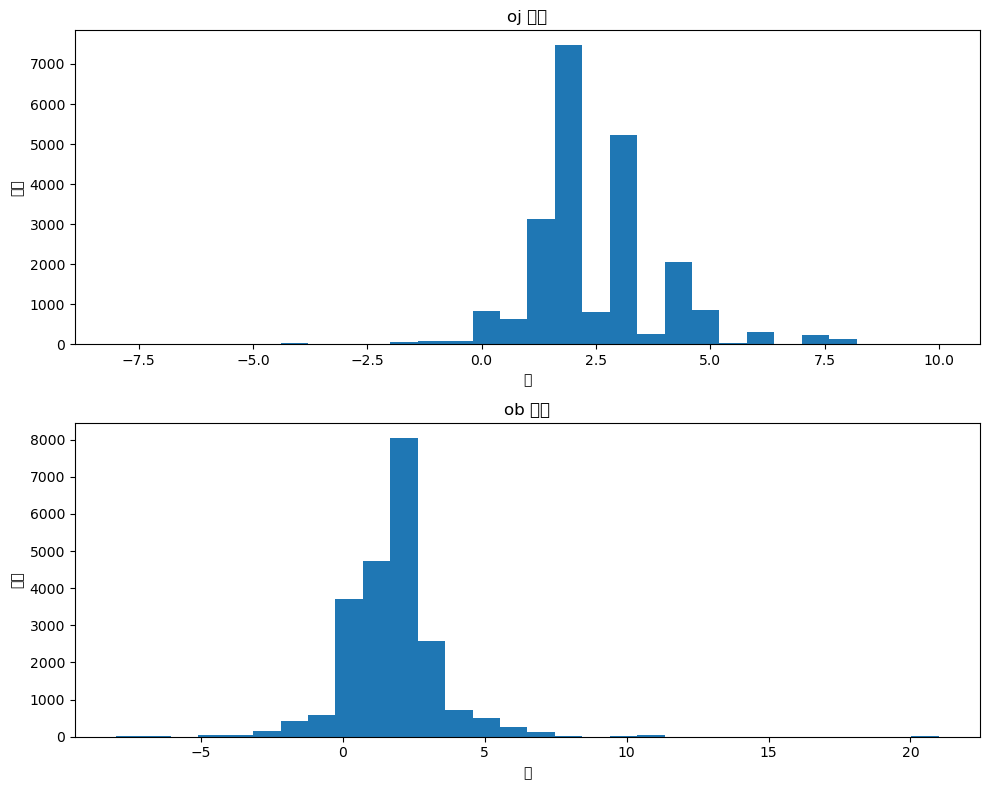

In [59]:
# 수치형 열만 선택하여 min, max 값 확인
numeric_columns = df.select_dtypes(include=['number']).columns

# 각 수치형 열의 min, max 값 출력
print("수치형 열의 최소값과 최대값:")
for col in numeric_columns:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col}: 최소값 = {min_val}, 최대값 = {max_val}")

# 이상치가 있을 수 있는 열들 확인 (예: 매우 큰 값이나 음수 값)
print("\n이상치가 의심되는 열:")
for col in numeric_columns:
    if df[col].max() > 100 or df[col].min() < 0:  # 임의의 기준
        print(f"{col}: 범위 = {df[col].min()} ~ {df[col].max()}")
        
# 특정 열에 대한 분포 확인 (예시)
import matplotlib.pyplot as plt

# 중요 측정값들의 분포 시각화
important_cols = ['CMO_before', 'CMO_after', 'MMO_before', 'MMO_after', 'oj', 'ob']
important_cols = [col for col in important_cols if col in numeric_columns]

if len(important_cols) > 0:
    fig, axes = plt.subplots(len(important_cols), 1, figsize=(10, 4*len(important_cols)))
    if len(important_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(important_cols):
        axes[i].hist(df[col].dropna(), bins=30)
        axes[i].set_title(f'{col} 분포')
        axes[i].set_xlabel('값')
        axes[i].set_ylabel('빈도')
    
    plt.tight_layout()
    plt.show()


In [60]:
df.to_parquet('../../data/centum_data_numeric_cleaned.parquet')